In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Load dataset
df = pd.read_csv('goog.csv',thousands=',')

# Display first rows
df.head()

,Date,Open,High,Low,Close,Volume
0,1/3/2012,325.25,332.83,324.97,663.59,7380500
1,1/4/2012,331.27,333.87,329.08,666.45,5749400
2,1/5/2012,329.83,330.75,326.89,657.21,6590300
3,1/6/2012,328.34,328.77,323.68,648.24,5405900
4,1/9/2012,322.04,322.29,309.46,620.76,11688800


In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1258 non-null   str    
 1   Open    1258 non-null   float64
 2   High    1258 non-null   float64
 3   Low     1258 non-null   float64
 4   Close   1258 non-null   float64
 5   Volume  1258 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 59.1 KB


In [49]:
# Use only 'Close' price for prediction
data = df['Close'].values.reshape(-1,1)

In [50]:
from sklearn.preprocessing import MinMaxScaler
# Scale values between 0 and 1
scaler = MinMaxScaler()
data = scaler.fit_transform(data)

In [51]:
# Train-Test Split
train_size = int(len(data) * 0.8)

train = data[:train_size]
test = data[train_size:]

In [ ]:
# Create time series sequences
def create_dataset(data, step=4):
    X, y = [], []
    for i in range(len(data)-step):
        X.append(data[i:i+step])  # Input: prices at positions i, i+1, i+2, i+3
        y.append(data[i])          # Output: price at position i (ALREADY KNOWN!)
    return np.array(X), np.array(y)

X_train, y_train = create_dataset(train)
X_test, y_test = create_dataset(test)

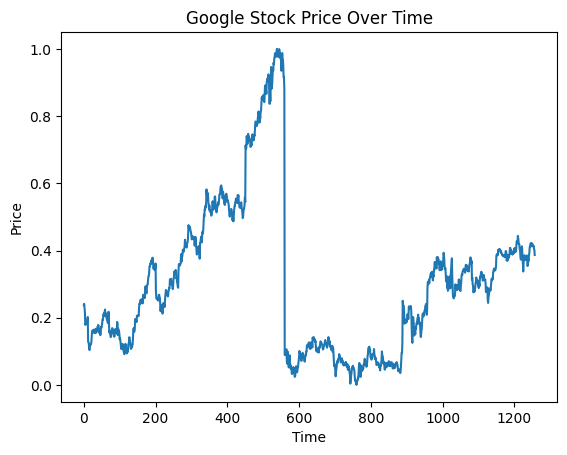

In [53]:
plt.plot(data)
plt.title("Google Stock Price Over Time")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

In [54]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense, Dropout
# Build Simple RNN model
model_rnn = Sequential()

model_rnn.add(SimpleRNN(64, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model_rnn.add(Dropout(0.2))
model_rnn.add(SimpleRNN(32))
model_rnn.add(Dropout(0.2))
model_rnn.add(Dense(1))

model_rnn.compile(optimizer='adam', loss='mean_squared_error')

# Train RNN
history_rnn = model_rnn.fit(X_train, y_train, epochs=30)

Epoch 1/30


/home/amey/Downloads/41335/.venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0818
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0151
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0092
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0084
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0066
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0063
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0056
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0045
Epoch 9/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0047
Epoch 10/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0045
Epoch 11/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0041
Epoch 12/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0044
Epoch 13/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0039
Epoch 14/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0032
Epoch 15/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0035
Epoch 16/30
32/32 ━━━━━━━━━━━━

In [55]:
# Predict using RNN
y_pred_rnn = model_rnn.predict(X_test)

# Convert back to original values
y_pred_rnn = scaler.inverse_transform(y_pred_rnn)
y_test_inv = scaler.inverse_transform(y_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


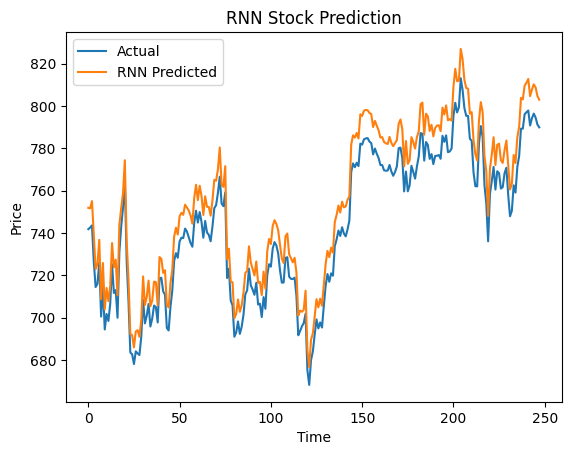

In [56]:
plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred_rnn, label='RNN Predicted')

plt.title("RNN Stock Prediction")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

In [57]:
# Build LSTM model
model_lstm = Sequential()

model_lstm.add(LSTM(64, return_sequences=True,input_shape=(X_train.shape[1], 1)))
model_lstm.add(Dropout(0.2))
model_lstm.add(LSTM(32))
model_lstm.add(Dropout(0.2))
model_lstm.add(Dense(1))

model_lstm.compile(optimizer='adam', loss='mean_squared_error')

# Train LSTM
history_lstm = model_lstm.fit(X_train, y_train, epochs=50)

Epoch 1/50


/home/amey/Downloads/41335/.venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0552
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0060
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0032
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0027
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0029
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0026
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0020    
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0022
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0017
Epoch 10/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0019    
Epoch 11/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0016    
Epoch 12/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0020
Epoch 13/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0021
Epoch 14/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0018
Epoch 15/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0019
Epoch 16/50
32/32 

In [58]:
# Predict using LSTM
y_pred_lstm = model_lstm.predict(X_test)

# Convert back to original values
y_pred_lstm = scaler.inverse_transform(y_pred_lstm)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


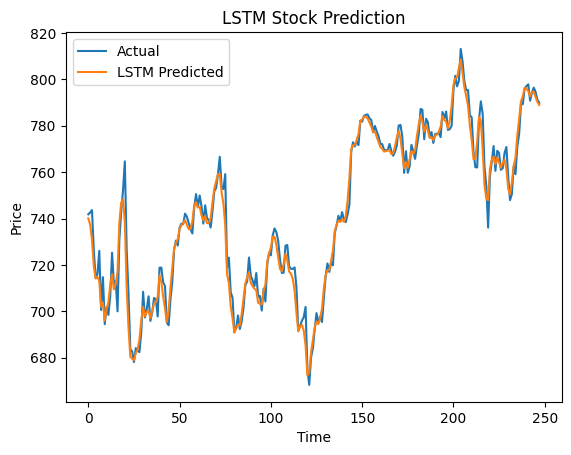

In [59]:
plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred_lstm, label='LSTM Predicted')

plt.title("LSTM Stock Prediction")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

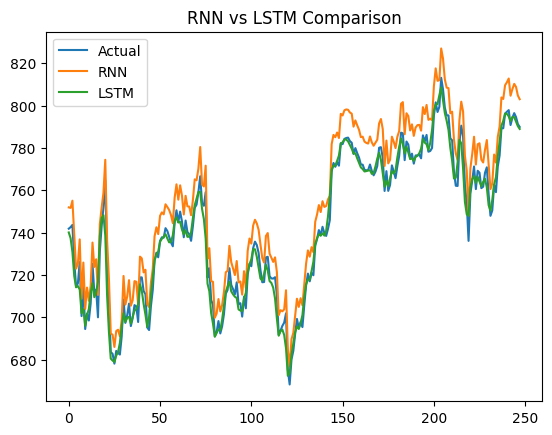

In [60]:
plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred_rnn, label='RNN')
plt.plot(y_pred_lstm, label='LSTM')

plt.title("RNN vs LSTM Comparison")
plt.legend()
plt.show()

In [61]:
from sklearn.metrics import mean_squared_error

rmse_rnn = np.sqrt(mean_squared_error(y_test_inv, y_pred_rnn))
rmse_lstm = np.sqrt(mean_squared_error(y_test_inv, y_pred_lstm))

print("RNN RMSE:", rmse_rnn)
print("LSTM RMSE:", rmse_lstm)

RNN RMSE: 11.851378704618915
LSTM RMSE: 5.2913963251267795
